In [2]:
import random
import torch
from datasets import load_dataset, DatasetDict
from transformers import BertTokenizerFast, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.metrics import f1_score


In [ ]:
dataset = load_dataset("dair-ai/emotion")
dataset = dataset.shuffle(seed=42)
dataset = DatasetDict({
    "train": dataset["train"].select(range(900)),
    "validation": dataset["validation"].select(range(100)),
    "test": dataset["test"].select(range(100))
})

labels = dataset["train"].features["label"].names
num_labels = len(labels)
print("Labels:", labels)

Labels: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [ ]:
def evaluate_random(dataset_split):
    y_true = dataset_split["label"]
    y_pred = [random.randint(0, num_labels - 1) for _ in y_true]

    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(num_labels)), zero_division=0
    )

    f1_micro = f1_score(y_true, y_pred, average="micro", zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    cm = confusion_matrix(y_true, y_pred)

    return acc, precision, recall, f1, (f1_micro, f1_macro, f1_weighted), cm

In [ ]:
pretrained = "bert-base-uncased"
tokenizer = BertTokenizerFast.from_pretrained(pretrained)

MAX_LEN = 32

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=MAX_LEN)

dataset = dataset.map(tokenize, batched=True)
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

train_loader = torch.utils.data.DataLoader(dataset["train"], batch_size=16, shuffle=True)
val_loader = torch.utils.data.DataLoader(dataset["validation"], batch_size=32)
test_loader = torch.utils.data.DataLoader(dataset["test"], batch_size=32)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BertForSequenceClassification.from_pretrained(pretrained, num_labels=num_labels).to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)
num_epochs = 2

num_training_steps = num_epochs * len(train_loader)
num_warmup_steps = int(0.1 * num_training_steps)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps)

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} - Loss: {total_loss / len(train_loader):.4f}")


Epoch 1: 100%|██████████| 57/57 [04:03<00:00,  4.27s/it]


Epoch 1 - Loss: 1.6719


Epoch 2: 100%|██████████| 57/57 [04:04<00:00,  4.28s/it]

Epoch 2 - Loss: 1.4899


In [27]:
def evaluate_model(model, dataloader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for batch in dataloader:
            labels = batch["label"].to(device)
            batch_inputs = {k: v.to(device) for k, v in batch.items() if k != "label"} 
            
            outputs = model(**batch_inputs, labels=labels)
            preds = torch.argmax(outputs.logits, dim=1).cpu().tolist()

            y_pred.extend(preds)
            y_true.extend(labels.cpu().tolist())

    acc = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(num_labels)), zero_division=0
    )

    f1_micro = f1_score(y_true, y_pred, average="micro", zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    cm = confusion_matrix(y_true, y_pred)

    return acc, precision, recall, f1, (f1_micro, f1_macro, f1_weighted), cm

In [ ]:
acc_rand, prec_rand, rec_rand, f1_rand, f1avg_rand, cm_rand = evaluate_random(dataset["test"])
acc_bert, prec_bert, rec_bert, f1_bert, f1avg_bert, cm_bert = evaluate_model(model, test_loader)




====== RANDOM MODEL ======
Accuracy: 0.18
Precision: [0.15789474 0.46666667 0.         0.2        0.36363636 0.        ]
Recall: [0.1        0.18421053 0.         0.30769231 0.36363636 0.        ]
F1: [0.12244898 0.26415094 0.         0.24242424 0.36363636 0.        ]
F1 avg (micro, macro, weighted): (0.18, 0.16544342150811153, 0.20862720388326855)

====== BERT MODEL ======
Accuracy: 0.57
Precision: [0.47619048 0.64814815 0.         0.5        0.         0.        ]
Recall: [0.66666667 0.92105263 0.         0.15384615 0.         0.        ]
F1: [0.55555556 0.76086957 0.         0.23529412 0.         0.        ]
F1 avg (micro, macro, weighted): (0.57, 0.25861987307000095, 0.486385336743393)


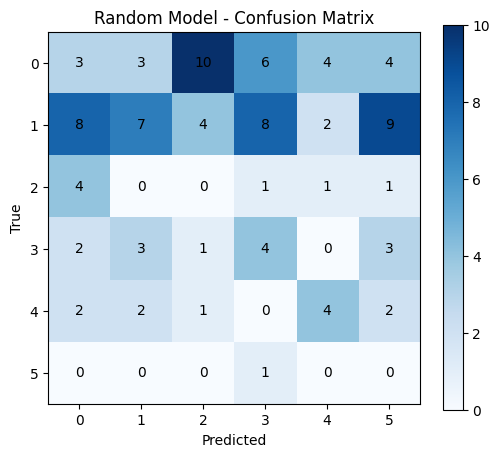

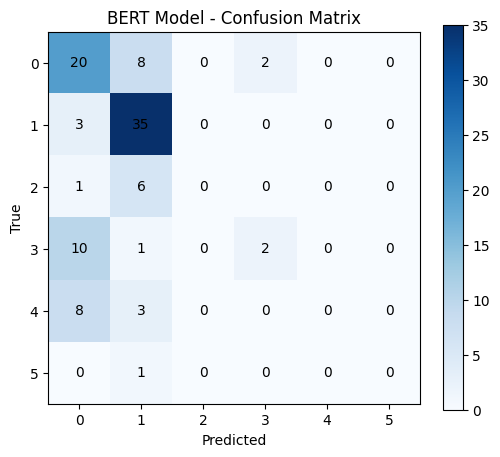

In [25]:
print("\n====== RANDOM MODEL ======")
print("Accuracy:", acc_rand)
print("Precision:", prec_rand)
print("Recall:", rec_rand)
print("F1:", f1_rand)
print("F1 avg (micro, macro, weighted):", f1avg_rand)

print("\n====== BERT MODEL ======")
print("Accuracy:", acc_bert)
print("Precision:", prec_bert)
print("Recall:", rec_bert)
print("F1:", f1_bert)
print("F1 avg (micro, macro, weighted):", f1avg_bert)

def plot_cm(cm, title):
    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()

    for i in range(num_labels):
        for j in range(num_labels):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.show()

plot_cm(cm_rand, "Random Model - Confusion Matrix")
plot_cm(cm_bert, "BERT Model - Confusion Matrix")


### Analysis of Model Results on the `dair-ai/emotion` Dataset

#### 1. Accuracy Comparison
- **Random model:** 0.18  
- **BERT model:** 0.57  

At first glance, BERT clearly outperforms the random classifier. However, **accuracy alone does not provide a complete picture**, especially for imbalanced classes. In emotion datasets, some classes appear less frequently, so a high accuracy does not guarantee that the model correctly predicts all classes.

---

#### 2️. Precision, Recall, and F1 per Class
- **Random model:**  
  - Some classes have F1 = 0 (the model never predicts them).  
  - Precision and recall are very unstable because random guessing produces mostly accidental hits.  
- **BERT model:**  
  - F1 scores for the most frequent classes are much higher (e.g., classes 0, 1, 3), but some classes still have F1 = 0 → the model essentially ignores rare classes.  
  - Precision is high for frequently predicted classes, while recall is low for classes that appear less often.

**Conclusion:** BERT significantly improves predictions for dominant classes, but rare classes remain challenging. The random model ignores most classes entirely.

---

#### 3️. Accuracy Sensitivity to Imbalanced Classes
Accuracy can be misleading: if one class dominates, a model that always predicts that class may have high accuracy, even though it fails to recognize other classes. Therefore, it is important to also look at precision, recall, and F1 to properly evaluate the model's performance for each class.

---

#### 4️. What Precision, Recall, and F1 Tell Us
- **Precision:** the proportion of predicted examples of a class that are correct.  
- **Recall:** the proportion of actual examples of a class that are correctly identified.  
- **F1:** balances precision and recall.  

These metrics reveal which classes are ignored and how the model handles rare classes. Information that accuracy alone cannot show.

---

#### 5️. Differences in Confusion Matrices
- **Random model:** errors are scattered randomly, with no patterns.  
- **BERT model:** errors are concentrated in rare classes, while the model performs well on dominant classes. The confusion matrix shows more meaningful errors, such as confusing similar emotions.

---

#### Summary
- Accuracy gives a general sense of performance but does not reveal issues with rare classes.  
- Precision, recall, and F1 provide a more detailed evaluation for each class.  
- **Random model:** low performance, random errors.  
- **BERT model:** much better performance for dominant classes but still ignores some rare classes; errors are more logical and predictable.
